# **Klasifikasi Negara | K-Means Clustering ++**

Model mengklasifikasikan negara pada kelompok tertentu berdasarkan karaktersitik menggunakan algoritma K-Means Clustering.

## 1. Data Preparation

### 1.1 Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk
from tkinter import messagebox

## 1.2 Read Dataset

In [2]:
df = pd.read_csv('Country-data.csv')

In [3]:
# 5 baris terats
print('5 baris teratas:')
df.head()

5 baris teratas:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
# Dimensi data
print('Jumlah baris:',df.shape[0])
print('Jumlah kolom:',df.shape[1])

Jumlah baris: 167
Jumlah kolom: 10


In [5]:
# Ringkasan informasi
print('Ringkasan informasi:')
df.info()

Ringkasan informasi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
# Ringkasan statistik
print('Ringkasan statistik:')
df.describe()

Ringkasan statistik:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [7]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

In [8]:
print('Cek nilai unik pada kolom kategori: ')
for col in categorical_columns:
    print(col, df[col].unique())


Cek nilai unik pada kolom kategori: 
country ['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas'
 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin'
 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada'
 'Cape Verde' 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo, Dem. Rep.' 'Congo, Rep.' 'Costa Rica' "Cote d'Ivoire"
 'Croatia' 'Cyprus' 'Czech Republic' 'Denmark' 'Dominican Republic'
 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Estonia'
 'Fiji' 'Finland' 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana'
 'Greece' 'Grenada' 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti'
 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran' 'Iraq' 'Ireland' 'Israel'
 'Italy' 'Jamaica' 'Japan' 'Jordan' 'Kazakhstan' 'Kenya' 'Kiribati'
 'Kuwait' 'Kyrgyz Republic' 'L

## 2. Exploratory Data Analysis (EDA)

### 2.1 Outlier

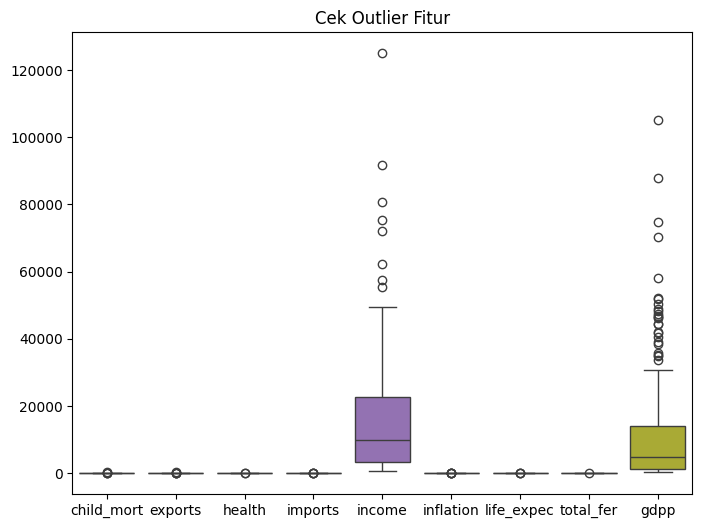

In [9]:
plt.figure(figsize=(8,6))
sns.boxplot(df)
plt.title(f'Cek Outlier Fitur')
plt.show()

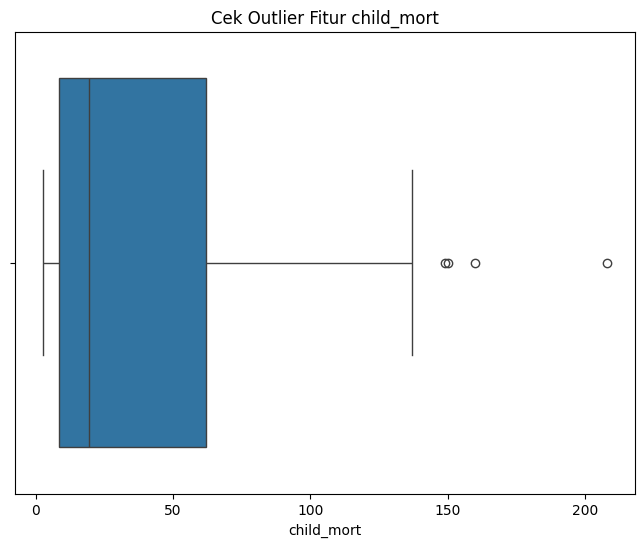

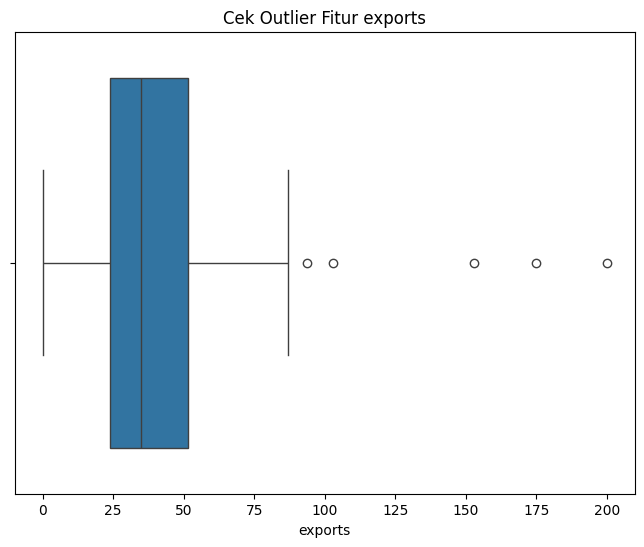

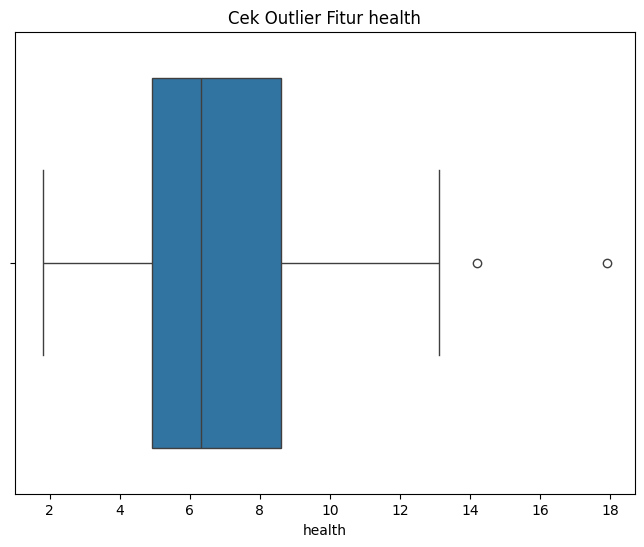

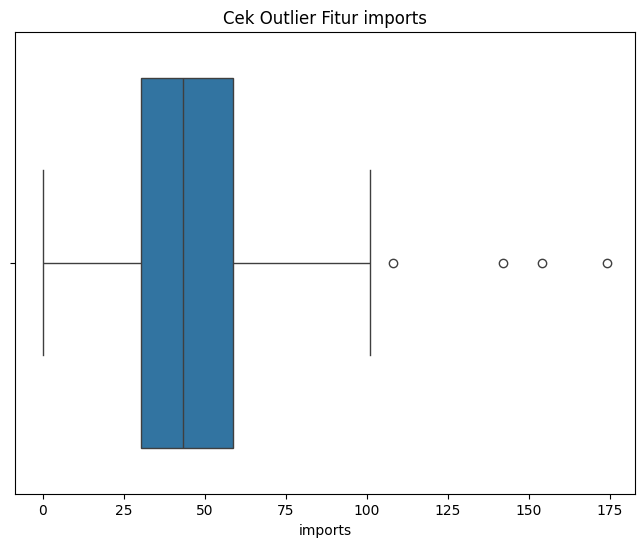

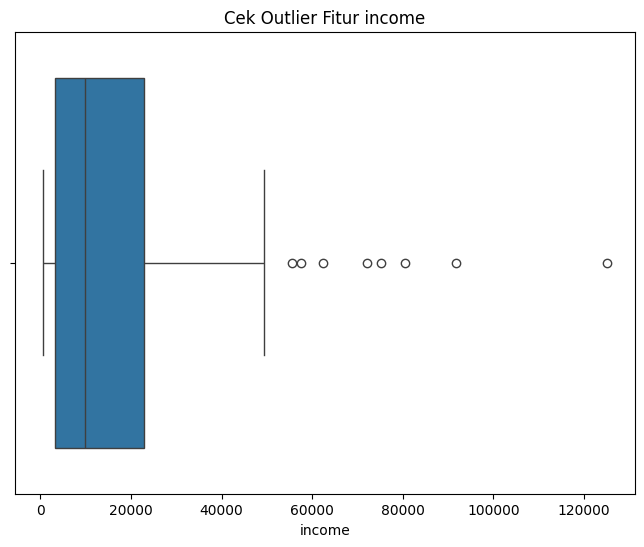

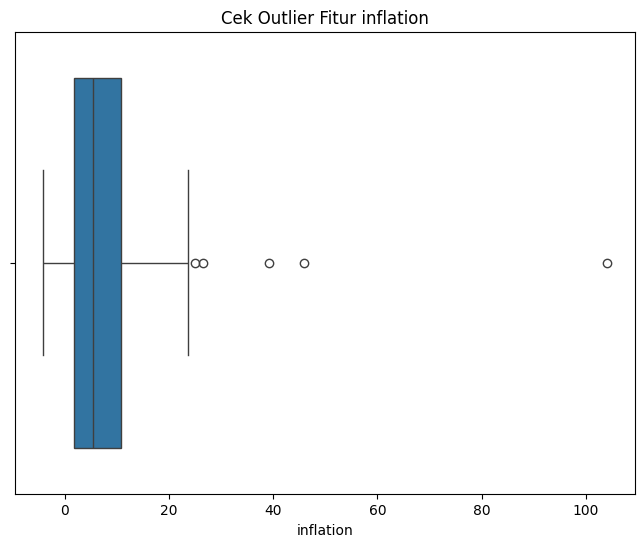

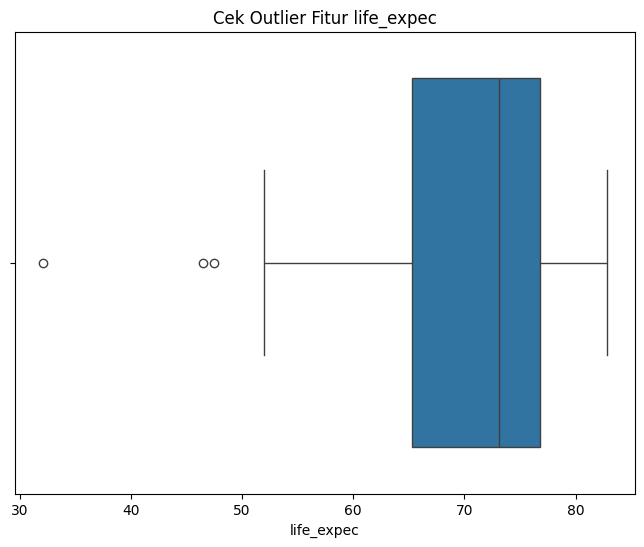

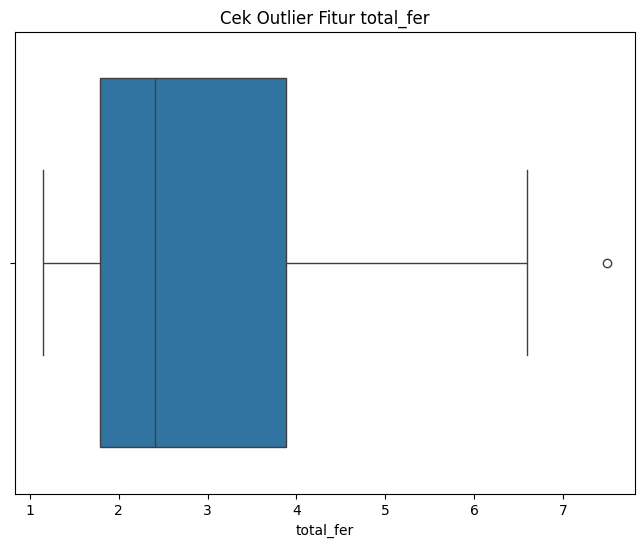

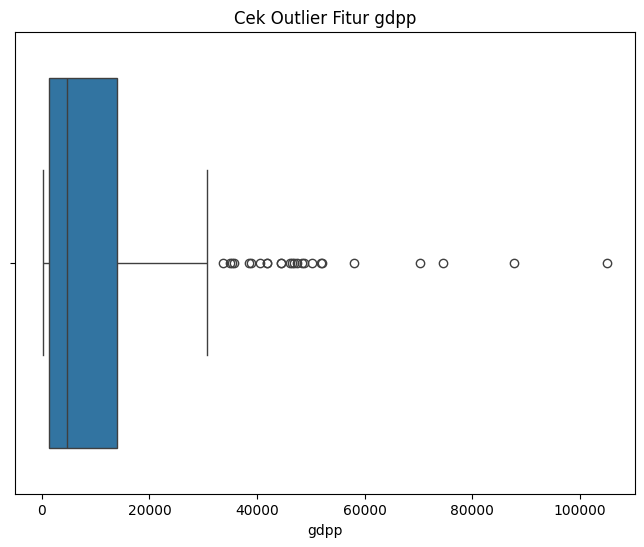

In [10]:
idx = 0
for col in numerical_columns:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col])
    plt.title(f'Cek Outlier Fitur {col}')
    idx += 1
    plt.show()


In [11]:
for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Clipping ringan
    df[col] = df[col].clip(lower, upper)

# Log hanya fitur tertentu
for col in ['income', 'gdpp']:
    df[col] = np.log1p(df[col])


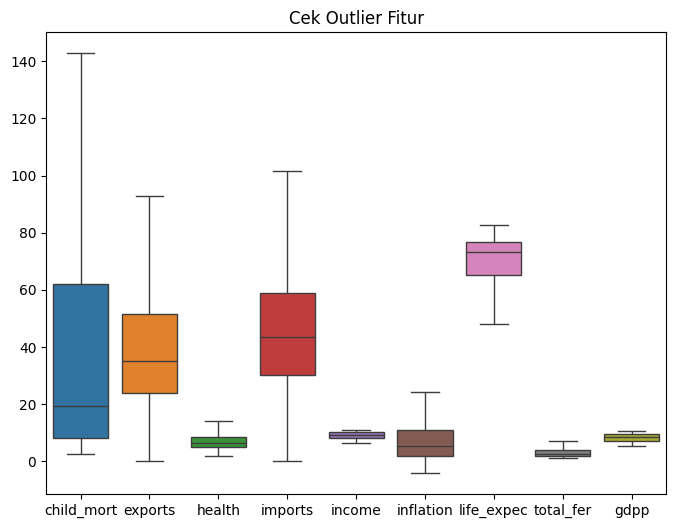

In [12]:
plt.figure(figsize=(8,6))
sns.boxplot(df)
plt.title(f'Cek Outlier Fitur')
plt.show()

## 3. Model 

In [13]:
data_df = np.log(df[numerical_columns])

min = data_df.min()
max = data_df.max()
data = (data_df - min) / (max - min)

/home/akyr/Documents/Akyr/hai/.venv/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [14]:
def d(dot1, dot2):
    dist = dot1 - dot2
    if dist < 0:
        return -dist
    return dist

In [15]:
center = [data.iloc[0].values]

dist_far = -1
dot_far = None

for dot in data:
    dist = d(dot, center[0])
    if dist > dist_far:
        dist_far = dist
        dot_far = dot
center.append(dot_far)

UFuncTypeError: ufunc 'subtract' did not contain a loop with signature matching types (dtype('<U10'), dtype('float64')) -> None

In [ ]:
for i in range(5):
    a = []
    b = []

    for dot in data:
        dist_to_a = d(dot, center[0])
        dist_to_b = d(dot, center[1])

        if dist_to_a < dist_to_b:
            a.append(dot)
        else:
            b.append(dot)

    if a:
        center[0] = sum(a) / len(a)
    if b:
        center[1] = sum(b) / len(b)
    print(f"Putaran {i+1}: Grup A={a}, Grup B={b}, Pusat baru={center}")

TypeError: unsupported operand type(s) for -: 'str' and 'str'

## 4. Evaluasi 